Device: NVIDIA GeForce RTX 5070
X_min: 0.0 X_train_max: 1.0
X_train shape: (966, 1, 50, 37)
Epoch  1/80 | Train 35.10% | Val 46.39%
Epoch 10/80 | Train 91.45% | Val 87.11%
Epoch 20/80 | Train 97.28% | Val 91.24%
Epoch 30/80 | Train 100.00% | Val 93.81%
Epoch 40/80 | Train 100.00% | Val 93.81%
Epoch 50/80 | Train 100.00% | Val 94.33%
Epoch 60/80 | Train 100.00% | Val 94.33%
Epoch 70/80 | Train 99.22% | Val 93.81%
Epoch 80/80 | Train 100.00% | Val 93.81%
Training time: 3.00s
Best validation accuracy: 94.85%
Test accuracy: 94.41%
                   precision    recall  f1-score   support

     Ariel Sharon       0.67      0.92      0.77        13
     Colin Powell       0.95      0.93      0.94        60
  Donald Rumsfeld       1.00      0.78      0.88        27
    George W Bush       0.99      1.00      0.99       146
Gerhard Schroeder       0.96      0.96      0.96        25
      Hugo Chavez       0.80      0.80      0.80        15
       Tony Blair       0.92      0.92      0.92     

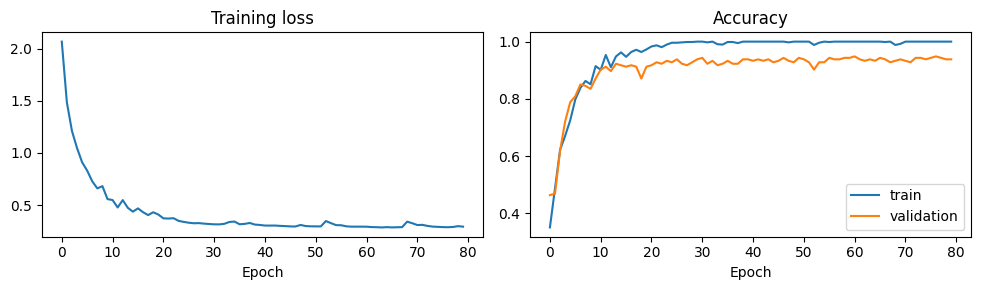

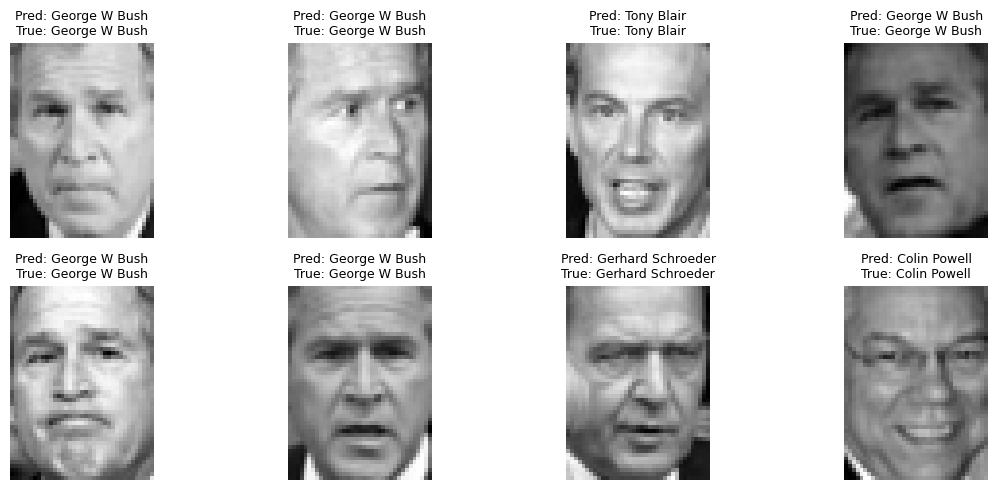

In [1]:
# Part 3.1: LFW CNN
%matplotlib inline

import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Run settings
SEED, EPOCHS, BATCH_SIZE = 42, 80, 64
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("Device:", torch.cuda.get_device_name(0) if device.type == "cuda" else device)

# Data
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# The following code could be used for data preprocessing if using pytorch
X, Y = lfw_people.images, lfw_people.target

# Verify the value range of X_train. No normalization is necessary in this case,
# as the input values already fall within the range of 0.0 to 1.0.
print("X_min:", X.min(), "X_train_max:", X.max())

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42
)

X_train = X_train[:, np.newaxis, :, :]
X_test = X_test[:, np.newaxis, :, :]
print("X_train shape:", X_train.shape)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

# Standardization uses training data only
mean, std = X_train.mean(), X_train.std()

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std


def make_loader(images, labels, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(images, dtype=torch.float32),
        torch.tensor(labels, dtype=torch.long)
    )
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle
    )


train_loader = make_loader(X_train, y_train, True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test, y_test)

h, w = X.shape[1:]
names = lfw_people.target_names


# Two 3x3 convolutional layers with 32 filters,
# followed by dense classification
class LFWCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32 * (h // 4) * (w // 4), 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, len(names))
        )

    def forward(self, images):
        return self.network(images)


@torch.no_grad()
def evaluate(model, data_loader):
    model.eval()
    predictions = []
    targets = []

    for images, labels in data_loader:
        logits = model(images.to(device))
        predictions.append(logits.argmax(1).cpu())
        targets.append(labels)

    predictions = torch.cat(predictions)
    targets = torch.cat(targets)
    accuracy = (predictions == targets).float().mean().item()

    return accuracy, predictions, targets


# Training
model = LFWCNN().to(device)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

history = []
best_accuracy = 0.0
best_state = None
started = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    model.train()

    correct = 0
    count = 0
    epoch_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        flip = torch.rand(
            len(images), 1, 1, 1, device=device
        ) < 0.5

        images = torch.where(
            flip,
            images.flip(-1),
            images
        )

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        count += len(labels)

    train_accuracy = correct / count
    val_accuracy, _, _ = evaluate(model, val_loader)

    history.append(
        (epoch_loss / count, train_accuracy, val_accuracy)
    )

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_state = copy.deepcopy(model.state_dict())

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:2d}/{EPOCHS} | "
            f"Train {train_accuracy:.2%} | "
            f"Val {val_accuracy:.2%}"
        )


# Final test
model.load_state_dict(best_state)

test_accuracy, predictions, targets = evaluate(
    model,
    test_loader
)

print(f"Training time: {time.perf_counter() - started:.2f}s")
print(f"Best validation accuracy: {best_accuracy:.2%}")
print(f"Test accuracy: {test_accuracy:.2%}")

print(
    classification_report(
        targets,
        predictions,
        target_names=names,
        zero_division=0
    )
)

torch.save(best_state, "lfw_cnn_best.pt")


# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot([row[0] for row in history])
axes[0].set(
    title="Training loss",
    xlabel="Epoch"
)

axes[1].plot(
    [row[1] for row in history],
    label="train"
)
axes[1].plot(
    [row[2] for row in history],
    label="validation"
)
axes[1].set(
    title="Accuracy",
    xlabel="Epoch"
)
axes[1].legend()

plt.tight_layout()
plt.show()


# Example predictions
fig, axes = plt.subplots(2, 4, figsize=(12, 5))

for i, axis in enumerate(axes.flat):
    axis.imshow(
        X_test[i, 0] * std + mean,
        cmap="gray"
    )
    axis.set_title(
        f"Pred: {names[predictions[i]]}\n"
        f"True: {names[targets[i]]}",
        fontsize=9
    )
    axis.axis("off")

plt.tight_layout()
plt.show()